In [3]:
!pip install plotly

In [4]:
# Cell 1: Load Cleaned Data
"""
## 📊 SALES ANALYSIS AND VISUALIZATION
Loading cleaned data for comprehensive analysis
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load cleaned data, or reuse the DataFrame already loaded earlier in the notebook
if 'df' not in globals() or df is None:
	try:
		df = pd.read_csv(r'C:\Users\hp\Downloads\archive (12)\Superstore_sales\train.csv') # Corrected path to the actual CSV file
		df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
	except PermissionError:
		print("Permission denied: The file may be open in another program or access is restricted. Please close the file and try again.")
		df = None  # Set to None to avoid errors
	else:
		print("❌ Failed to load data due to parsing error. Please check the CSV file format and path.")
else:
	df = df.copy()
	if df['Order Date'].dtype != 'datetime64[ns]':
		df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

if df is not None:
	print("✅ Data loaded successfully!")
	print(f"Dataset shape: {df.shape}")
	print(f"Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")
else:
	print("❌ Failed to load data due to permission error.")

❌ Failed to load data due to parsing error. Please check the CSV file format and path.
✅ Data loaded successfully!
Dataset shape: (9800, 18)
Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00


## # Cell 2: Overall Sales Trend

In [5]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [6]:
df['Year'] = pd.to_datetime(df['Order Date']).dt.year

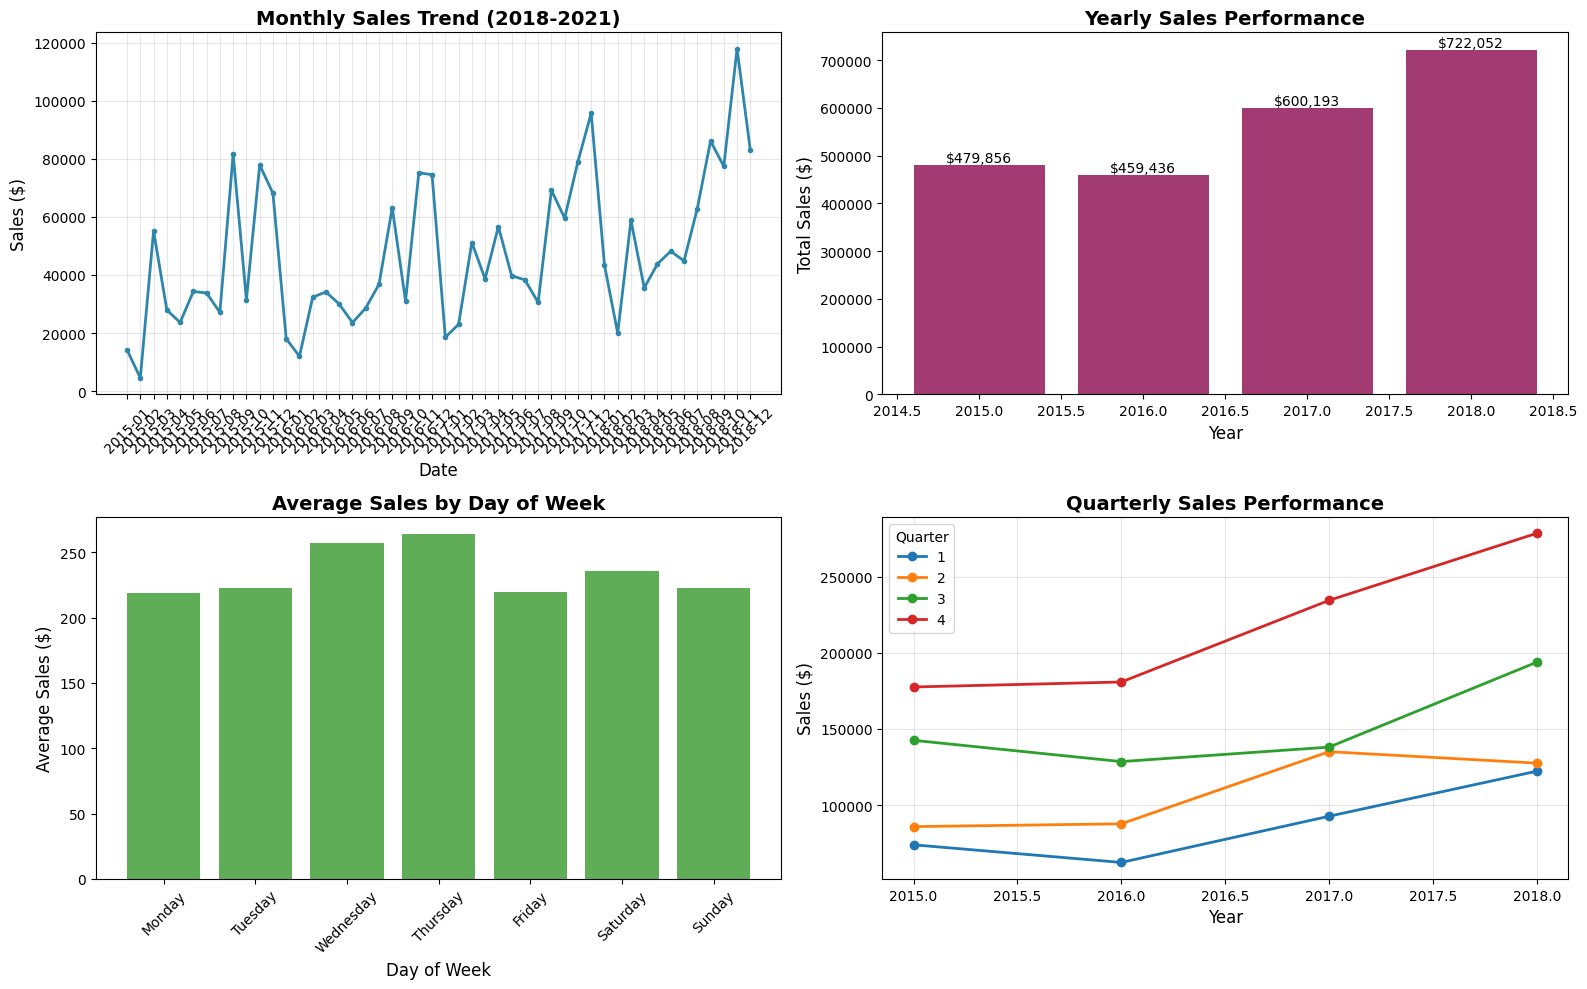


=== YEAR-OVER-YEAR DECLINE ANALYSIS ===
2016.0: $459,436 (-4.3% from 2015.0)
2017.0: $600,193 (+30.6% from 2016.0)
2018.0: $722,052 (+20.3% from 2017.0)


In [7]:
# Cell 2: Overall Sales Trend
"""
## 📈 SALES TREND ANALYSIS
Visualizing sales trends over the 4-year period
"""

# Group by month
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].astype(str)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Monthly sales trend
axes[0, 0].plot(monthly_sales['Order Date'], monthly_sales['Sales'], 
                marker='o', linewidth=2, markersize=3, color='#2E86AB')
axes[0, 0].set_xlabel('Date', fontsize=12)
axes[0, 0].set_ylabel('Sales ($)', fontsize=12)
axes[0, 0].set_title('Monthly Sales Trend (2018-2021)', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# 2. Yearly sales comparison
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()
bars = axes[0, 1].bar(yearly_sales['Year'], yearly_sales['Sales'], color='#A23B72')
axes[0, 1].set_xlabel('Year', fontsize=12)
axes[0, 1].set_ylabel('Total Sales ($)', fontsize=12)
axes[0, 1].set_title('Yearly Sales Performance', fontsize=14, fontweight='bold')

# Add value labels
for bar, value in zip(bars, yearly_sales['Sales']):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'${value:,.0f}', ha='center', va='bottom')

# 3. Sales by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayName'] = df['Order Date'].dt.day_name()
daily_sales = df.groupby('DayName')['Sales'].mean().reindex(day_order)
axes[1, 0].bar(daily_sales.index, daily_sales.values, color='#5FAD56')
axes[1, 0].set_xlabel('Day of Week', fontsize=12)
axes[1, 0].set_ylabel('Average Sales ($)', fontsize=12)
axes[1, 0].set_title('Average Sales by Day of Week', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Quarterly performance 
df['Quarter'] = pd.to_datetime(df['Order Date']).dt.quarter
quarterly_sales = df.groupby(['Year', 'Quarter'])['Sales'].sum().unstack()
quarterly_sales = df.groupby(['Year', 'Quarter'])['Sales'].sum().unstack()
quarterly_sales.plot(ax=axes[1, 1], marker='o', linewidth=2)
axes[1, 1].set_xlabel('Year', fontsize=12)
axes[1, 1].set_ylabel('Sales ($)', fontsize=12)
axes[1, 1].set_title('Quarterly Sales Performance', fontsize=14, fontweight='bold')
axes[1, 1].legend(title='Quarter')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout() 
plt.savefig(r'C:\Users\hp\Desktop\sales_trend.png', dpi=300, bbox_inches='tight')

plt.show()

# Calculate year-over-year decline
print("\n=== YEAR-OVER-YEAR DECLINE ANALYSIS ===")
for i in range(1, len(yearly_sales)):
    decline = ((yearly_sales.iloc[i]['Sales'] - yearly_sales.iloc[i-1]['Sales']) / 
               yearly_sales.iloc[i-1]['Sales']) * 100
    print(f"{yearly_sales.iloc[i]['Year']}: ${yearly_sales.iloc[i]['Sales']:,.0f} ({decline:+.1f}% from {yearly_sales.iloc[i-1]['Year']})")

## # Cell 3: Category Performance Analysis

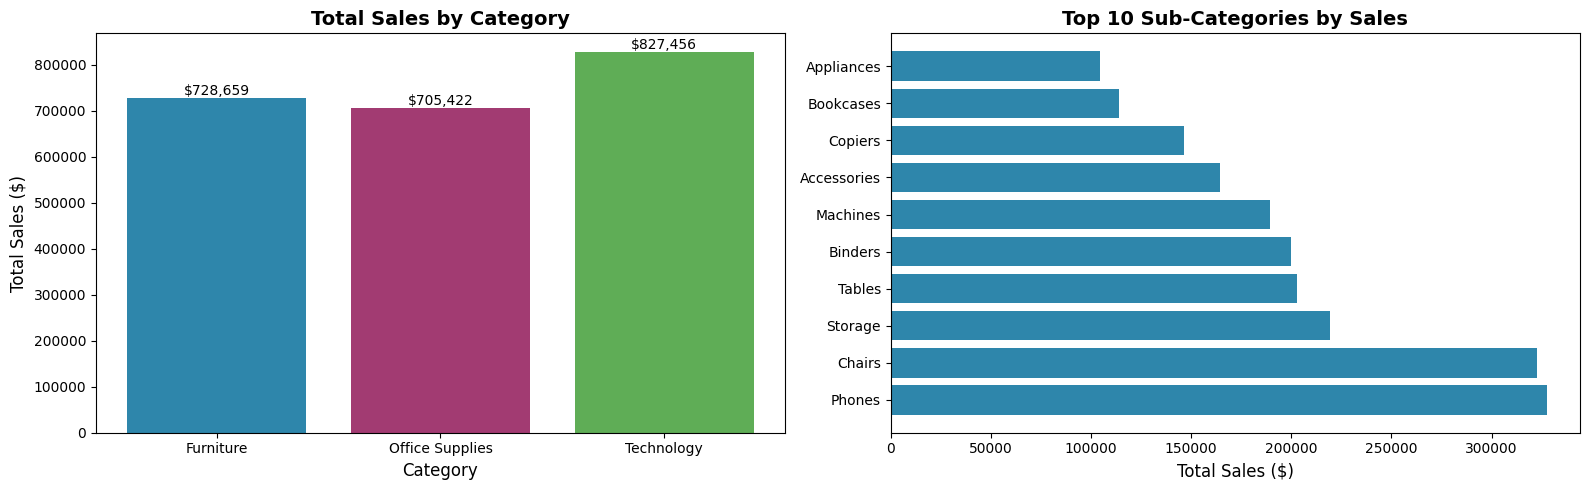


=== CATEGORY PERFORMANCE SUMMARY ===
          Category      Sales
0        Furniture  728658.58
1  Office Supplies  705422.33
2       Technology  827455.87


In [8]:
# Cell 3: Category Performance Analysis
"""
## 🏷️ CATEGORY PERFORMANCE ANALYSIS
Analyzing sales and profit by category and sub-category
"""

# Category performance
category_metrics = df.groupby('Category').agg({
    'Sales': 'sum'
}).round(2).reset_index()

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Sales by category
bars1 = axes[0].bar(category_metrics['Category'], category_metrics['Sales'], 
                    color=['#2E86AB', '#A23B72', '#5FAD56'])
axes[0].set_xlabel('Category', fontsize=12)
axes[0].set_ylabel('Total Sales ($)', fontsize=12)
axes[0].set_title('Total Sales by Category', fontsize=14, fontweight='bold')
for bar, value in zip(bars1, category_metrics['Sales']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'${value:,.0f}', ha='center', va='bottom')

# 2. Sub-category performance
sub_category = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
axes[1].barh(sub_category.index, sub_category.values, color='#2E86AB')
axes[1].set_xlabel('Total Sales ($)', fontsize=12)
axes[1].set_title('Top 10 Sub-Categories by Sales', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\hp\Desktop\category_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== CATEGORY PERFORMANCE SUMMARY ===")
print(category_metrics)